# Weighted Vision Transformer for Retinal OCT Disease Classification

This notebook implements a Vision Transformer model with weighted cross entropy for multiclass classification of retinal OCT images from the Kermany2018 dataset.

Unlike convolutional neural networks, Vision Transformer divides each image into patches and uses self-attention mechanisms to capture global visual relationships. Since the dataset is imbalanced, class weights are computed from the training distribution and incorporated into the cross-entropy loss function.

The model is evaluated using accuracy, precision, recall, F1-score, Macro F1-score, confusion matrix analysis, training time, and number of parameters.

In [2]:
!pip install -q timm

In [3]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

import timm

print("PyTorch version:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("Número de GPUs:", torch.cuda.device_count())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch version: 2.10.0+cu128
CUDA disponible: True
Número de GPUs: 2
Device: cuda


In [4]:
DATA_DIR = "/kaggle/input/datasets/fabrizioravelli/retinal-oct-images-splitted"

train_dir = os.path.join(DATA_DIR, "training", "train")
val_dir = os.path.join(DATA_DIR, "training", "val")
test_dir = os.path.join(DATA_DIR, "test")

print("Train existe:", os.path.exists(train_dir))
print("Val existe:", os.path.exists(val_dir))
print("Test existe:", os.path.exists(test_dir))

print("Clases:", os.listdir(train_dir))

Train existe: True
Val existe: True
Test existe: True
Clases: ['DRUSEN', 'CNV', 'NORMAL', 'DME']


In [6]:
IMG_SIZE = 224
BATCH_SIZE = 16
SEED = 42
EPOCHS = 20
PATIENCE = 5

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [8]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=eval_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transforms)

class_names = train_dataset.classes
NUM_CLASSES = len(class_names)

print("Clases:", class_names)
print("Número de clases:", NUM_CLASSES)
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Clases: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Número de clases: 4
Train: 61284
Val: 7659
Test: 7664


In [9]:
train_targets = np.array(train_dataset.targets)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_targets
)

class_weights_tensor = torch.tensor(
    class_weights_array,
    dtype=torch.float32
).to(device)

print("Class names:", class_names)
print("Class weights:", class_weights_array)
print("Class weights tensor:", class_weights_tensor)

Class names: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Class weights: [0.60533386 1.74340009 2.44900895 0.73201147]
Class weights tensor: tensor([0.6053, 1.7434, 2.4490, 0.7320], device='cuda:0')


In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

### Create Model

In [11]:
model = timm.create_model(
    "vit_small_patch16_224",
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=2e-5)

print(model.__class__.__name__)
print("Parámetros:", sum(p.numel() for p in model.parameters()))

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

VisionTransformer
Parámetros: 21667204


In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc


def evaluate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

In [13]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    patience,
    model_path,
    log_path
):
    history = {
        "loss": [],
        "accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }
    
    best_val_loss = np.inf
    patience_counter = 0
    start_time = time.time()
    
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        val_loss, val_acc = evaluate_one_epoch(
            model, val_loader, criterion, device
        )
        
        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)
        
        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )
        
        pd.DataFrame(history).to_csv(log_path, index=False)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), model_path)
            print("Best model saved.")
        else:
            patience_counter += 1
            print(f"EarlyStopping counter: {patience_counter}/{patience}")
            
        if patience_counter >= patience:
            print("Early stopping activated.")
            break
    
    end_time = time.time()
    training_time = end_time - start_time
    
    model.load_state_dict(torch.load(model_path, map_location=device))
    
    return history, training_time

## Train

In [14]:
history, training_time = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    patience=PATIENCE,
    model_path="vit_weighted_best_model.pth",
    log_path="vit_weighted_training_log.csv"
)

print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time/60:.2f} minutos")

Epoch 1/20 | Train Loss: 0.2554 | Train Acc: 0.9164 | Val Loss: 0.1428 | Val Acc: 0.9508
Best model saved.
Epoch 2/20 | Train Loss: 0.1713 | Train Acc: 0.9455 | Val Loss: 0.1423 | Val Acc: 0.9492
Best model saved.
Epoch 3/20 | Train Loss: 0.1448 | Train Acc: 0.9539 | Val Loss: 0.1423 | Val Acc: 0.9525
Best model saved.
Epoch 4/20 | Train Loss: 0.1241 | Train Acc: 0.9603 | Val Loss: 0.1389 | Val Acc: 0.9523
Best model saved.
Epoch 5/20 | Train Loss: 0.1062 | Train Acc: 0.9657 | Val Loss: 0.1087 | Val Acc: 0.9641
Best model saved.
Epoch 6/20 | Train Loss: 0.0949 | Train Acc: 0.9697 | Val Loss: 0.1153 | Val Acc: 0.9621
EarlyStopping counter: 1/5
Epoch 7/20 | Train Loss: 0.0867 | Train Acc: 0.9722 | Val Loss: 0.1110 | Val Acc: 0.9644
EarlyStopping counter: 2/5
Epoch 8/20 | Train Loss: 0.0778 | Train Acc: 0.9749 | Val Loss: 0.1221 | Val Acc: 0.9620
EarlyStopping counter: 3/5
Epoch 9/20 | Train Loss: 0.0695 | Train Acc: 0.9774 | Val Loss: 0.1249 | Val Acc: 0.9623
EarlyStopping counter: 4/5
E

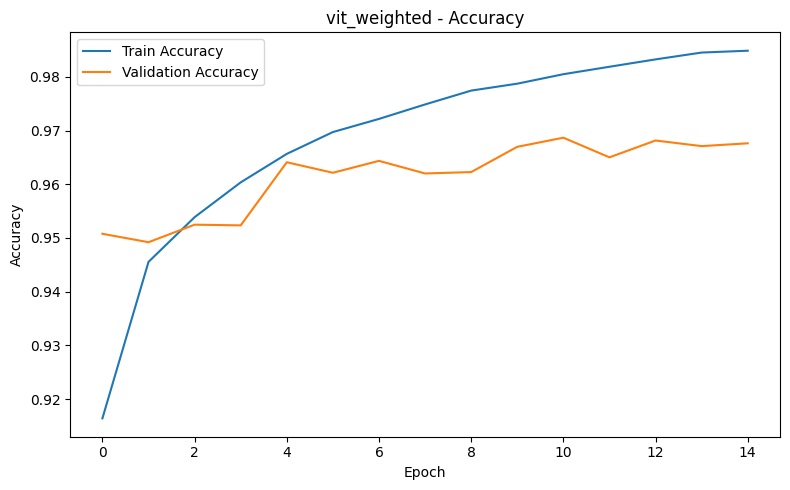

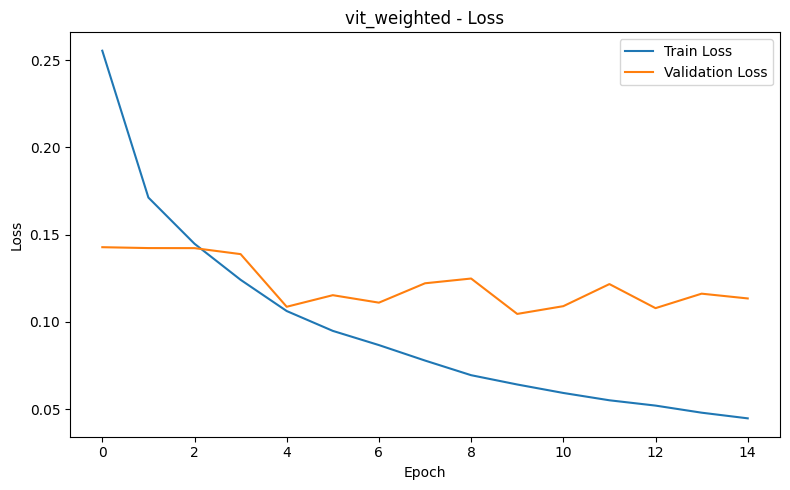

In [19]:
def plot_training_curves(history, model_name):
    plt.figure(figsize=(8, 5))
    plt.plot(history["accuracy"], label="Train Accuracy")
    plt.plot(history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{model_name}_accuracy_curve.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{model_name}_loss_curve.png", dpi=300)
    plt.show()

plot_training_curves(history, "vit_weighted")

In [20]:
def get_predictions(model, loader, device):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
    
    return np.array(y_true), np.array(y_pred)


y_true, y_pred = get_predictions(model, test_loader, device)

In [21]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()
df_report.to_csv("vit_weighted_classification_report.csv")

df_report

,precision,recall,f1-score,support
CNV,0.989372,0.970616,0.979904,3165.000000
DME,0.954914,0.963603,0.959239,1099.000000
DRUSEN,0.884094,0.915709,0.899624,783.000000
NORMAL,0.973475,0.981658,0.977549,2617.000000
accuracy,0.967771,0.967771,0.967771,0.967771
macro avg,0.950464,0.957897,0.954079,7664.000000
weighted avg,0.968247,0.967771,0.967935,7664.000000


In [22]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

         CNV       0.99      0.97      0.98      3165
         DME       0.95      0.96      0.96      1099
      DRUSEN       0.88      0.92      0.90       783
      NORMAL       0.97      0.98      0.98      2617

    accuracy                           0.97      7664
   macro avg       0.95      0.96      0.95      7664
weighted avg       0.97      0.97      0.97      7664



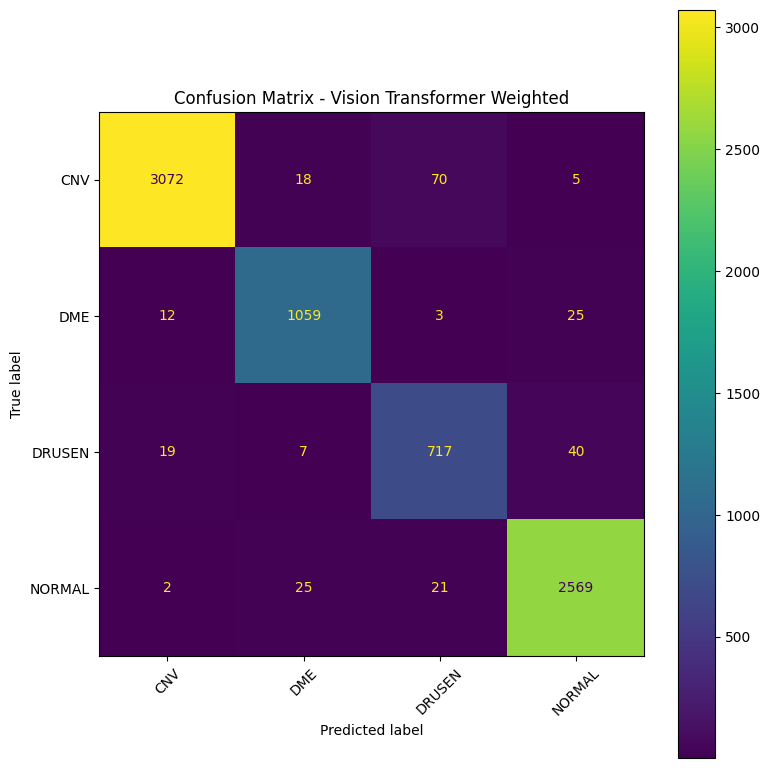

In [23]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix - Vision Transformer Weighted")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("vit_weighted_confusion_matrix.png", dpi=300)
plt.show()

In [24]:
metrics = {
    "model": "Vision Transformer Weighted",
    "accuracy": accuracy_score(y_true, y_pred),
    "precision_macro": precision_score(y_true, y_pred, average="macro"),
    "recall_macro": recall_score(y_true, y_pred, average="macro"),
    "f1_macro": f1_score(y_true, y_pred, average="macro"),
    "precision_weighted": precision_score(y_true, y_pred, average="weighted"),
    "recall_weighted": recall_score(y_true, y_pred, average="weighted"),
    "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
    "training_time_seconds": training_time,
    "training_time_minutes": training_time / 60,
    "epochs_trained": len(history["loss"])
}

df_metrics = pd.DataFrame([metrics])
df_metrics.to_csv("vit_weighted_metrics_summary.csv", index=False)

df_metrics

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,training_time_seconds,training_time_minutes,epochs_trained
0,Vision Transformer Weighted,0.967771,0.950464,0.957897,0.954079,0.968247,0.967771,0.967935,10405.722368,173.428706,15


In [25]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
non_trainable_params = total_params - trainable_params

params_summary = pd.DataFrame([{
    "model": "Vision Transformer Weighted",
    "total_params": total_params,
    "trainable_params": trainable_params,
    "non_trainable_params": non_trainable_params
}])

params_summary.to_csv("vit_weighted_params_summary.csv", index=False)
params_summary

,model,total_params,trainable_params,non_trainable_params
0,Vision Transformer Weighted,21667204,21667204,0
